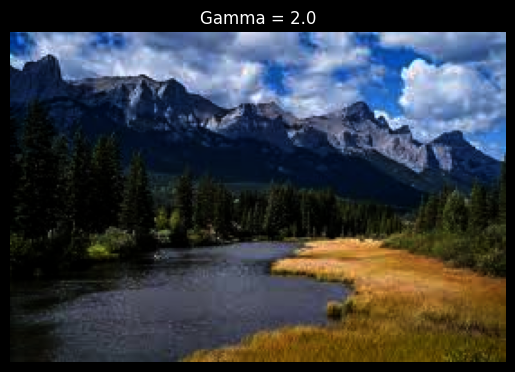

In [6]:
#Task 1
import cv2
import numpy as np

def gamma_correction(I_in, c, gamma):
    I_norm = I_in.astype('float32') / 255

    I_gamma = c * (I_norm ** gamma)

    I_out = np.clip(I_gamma, 0, 1)

    return I_out

image = cv2.imread("images/test_image_2.jpeg")
gamma = 2.0
c = 1

output = gamma_correction(image, c, gamma)
save_img = (output * 255).astype(np.uint8)
cv2.imwrite("images/result_gamma.jpg", save_img)

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor((output*255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title(f"Gamma = {gamma}")
plt.axis("off")
plt.show()

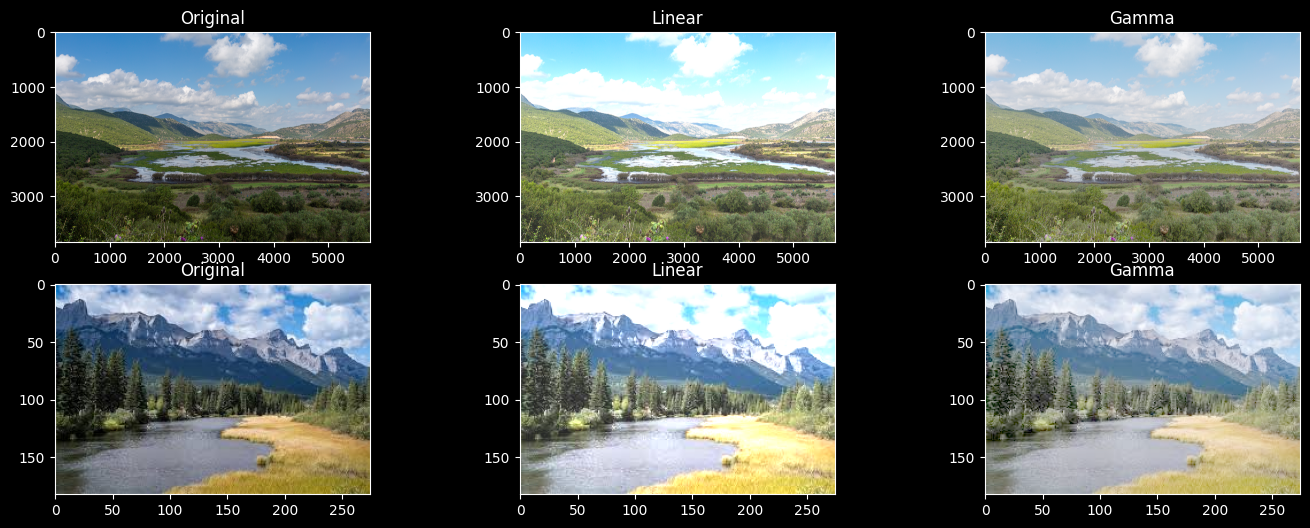

In [3]:
#Task 2
import cv2
import numpy as np
import matplotlib.pyplot as plt

gamma = 2.0

img_original1 = cv2.imread("images/test_image.jpg")
img_original2 = cv2.imread("images/test_image_2.jpeg")

if img_original1 is None:
    print("Error: Could not load test_image.jpg ")
    exit()
if img_original2 is None:
    print("Error: Could not load test_image_2.jpeg. Please ensure the file is uploaded.")
    img_original2_loaded = False
else:
    img_original2_loaded = True

output_linear1 = cv2.convertScaleAbs(img_original1, alpha=1.3, beta=40)
if img_original2_loaded:
    output_linear2 = cv2.convertScaleAbs(img_original2, alpha=1.3, beta=40)

lookUpTable = np.empty((1, 256), np.uint8)
for i in range(256):
    lookUpTable[0, i] = np.clip(pow(i / 255.0, gamma) * 255.0, 0, 255)

output_gamma_corrected1 = cv2.LUT(img_original1, lookUpTable)
if img_original2_loaded:
    output_gamma_corrected2 = cv2.LUT(img_original2, lookUpTable)

plt.figure(figsize=[17,6])

plt.subplot(231)
plt.imshow(img_original1[..., ::-1])
plt.title("Original")
plt.subplot(232)
plt.imshow(output_linear1[..., ::-1])
plt.title("Linear")
plt.subplot(233)
plt.imshow(output_gamma_corrected1[..., ::-1])
plt.title("Gamma")

if img_original2_loaded:
    plt.subplot(234)
    plt.imshow(img_original2[..., ::-1])
    plt.title("Original")
    plt.subplot(235)
    plt.imshow(output_linear2[..., ::-1])
    plt.title("Linear")
    plt.subplot(236)
    plt.imshow(output_gamma_corrected2[..., ::-1])
    plt.title("Gamma")

plt.show()
